#Lab Activity 05

**Keras** is a high-level API for building and training neural networks,
running on top of TensorFlow. The **Sequential API** is the simplest way to use
it: layers are stacked one after another.

Building a model in Keras is always the same three steps:

| Step | What happens |
|---|---|
| **Build** | Stack the layers — `Dense` (fully connected), `Flatten`, `Dropout`, and others |
| **Compile** | Choose a **loss function** and an **optimizer**, and the metrics to track |
| **Fit** | Train on the data for a number of epochs, then `evaluate` on the test set |

These activities build a network for MNIST handwritten digits, then change one
thing at a time to see what each hyperparameter does.

##Activity 1: Implementing an ANN in Keras

The dataset is MNIST — 70,000 greyscale images of handwritten digits, 28x28
pixels, in 10 classes.

**Preprocessing.** Pixel values are 0–255, so dividing by 255 puts them in 0–1;
neural networks train far better on small, uniformly scaled inputs. The labels
are **one-hot encoded**: the digit `3` becomes `[0,0,0,1,0,0,0,0,0,0]`, which is
the shape the 10-neuron softmax output layer produces.

**The architecture.** `Flatten` turns each 28x28 image into a flat vector of 784
values so it can be fed to `Dense` layers. Two hidden ReLU layers (128 and 64
neurons) do the work, and a 10-neuron **softmax** output turns the scores into
probabilities that sum to 1.

**Compiling.** `categorical_crossentropy` is the loss for multi-class
classification, and `adam` is an optimizer that adapts its learning rate as it
goes.

###Loading and preprocessing the data

In [1]:
import os
import logging
# Keep TensorFlow's start-up logging and deprecation notices out of the output
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
logging.getLogger("tensorflow").setLevel(logging.ERROR)

import numpy as np
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

# Load and preprocess the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Scale to 0-1 and cast to float32. Dividing a uint8 array gives float64,
# which doubles the memory the dataset needs for no benefit.
x_train = (x_train / 255.0).astype("float32")
x_test = (x_test / 255.0).astype("float32")

# One-hot encode the labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("Training images:", x_train.shape, "| labels:", y_train.shape)
print("Test images    :", x_test.shape, "| labels:", y_test.shape)
print("Pixel range    :", x_train.min(), "to", x_train.max())
print("One-hot example:", y_train[0])

Training images: (60000, 28, 28) | labels: (60000, 10)
Test images    : (10000, 28, 28) | labels: (10000, 10)
Pixel range    : 0.0 to 1.0
One-hot example: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


###Building, compiling and training the model

In [2]:
# The same random seed each run, so the numbers below are reproducible
keras.backend.clear_session()
keras.utils.set_random_seed(42)

# Build the neural network model
model = Sequential([
    Input(shape=(28, 28)),           # Input layer: one 28x28 image
    Flatten(),                       # Flatten the input images to a 1D vector
    Dense(128, activation='relu'),   # First hidden layer with 128 neurons
    Dense(64, activation='relu'),    # Second hidden layer with 64 neurons
    Dense(10, activation='softmax')  # Output layer, one neuron per class
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Train the model. 20% of the training data is held back to validate on.
history = model.fit(x_train, y_train, epochs=10, batch_size=32,
                    validation_split=0.2, verbose=2)

Epoch 1/10


1500/1500 - 12s - 8ms/step - accuracy: 0.9236 - loss: 0.2659 - val_accuracy: 0.9616 - val_loss: 0.1362


Epoch 2/10


1500/1500 - 9s - 6ms/step - accuracy: 0.9655 - loss: 0.1127 - val_accuracy: 0.9656 - val_loss: 0.1155


Epoch 3/10


...

1500/1500 - 9s - 6ms/step - accuracy: 0.9928 - loss: 0.0224 - val_accuracy: 0.9662 - val_loss: 0.1495


Epoch 9/10


1500/1500 - 9s - 6ms/step - accuracy: 0.9928 - loss: 0.0227 - val_accuracy: 0.9731 - val_loss: 0.1201


Epoch 10/10


1500/1500 - 9s - 6ms/step - accuracy: 0.9934 - loss: 0.0185 - val_accuracy: 0.9758 - val_loss: 0.1083


###Evaluating on the test set

In [4]:
# Evaluate the model on data it has never seen
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss    : {test_loss:.4f}')

baseline_accuracy = test_acc
hist_base = history.history   # keep the curves; the model itself is no longer needed

Test accuracy: 0.9748
Test loss    : 0.1009


##Activity 2: Experiments

Four experiments, each changing **one** thing from Activity 1 so the effect of
that change can be read on its own. Everything else — the data, the seed, the
loss function — stays the same.

| Experiment | Change |
|---|---|
| 1 | More neurons in the hidden layers: 256 and 128 |
| 2 | Activation changed from ReLU to sigmoid |
| 3 | Optimizer changed from adam to SGD |
| 4 | Epochs increased from 10 to 20 |

###Experiment 1: more neurons

Doubling the hidden layers to 256 and 128 neurons gives the network more
capacity — more weights with which to represent patterns.

In [5]:
keras.backend.clear_session()
keras.utils.set_random_seed(42)

model_1 = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),   # Changed to 256 neurons
    Dense(128, activation='relu'),   # Changed to 128 neurons
    Dense(10, activation='softmax')
])
model_1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_1 = model_1.fit(x_train, y_train, epochs=10, batch_size=32,
                        validation_split=0.2, verbose=2)

loss_1, acc_1 = model_1.evaluate(x_test, y_test, verbose=0)
print(f'\nExperiment 1 test accuracy: {acc_1:.4f}  (baseline {baseline_accuracy:.4f})')

# Keep the curves, release the model so memory does not build up
hist_1 = history_1.history
del model_1, history_1

Epoch 1/10


1500/1500 - 14s - 9ms/step - accuracy: 0.9333 - loss: 0.2280 - val_accuracy: 0.9654 - val_loss: 0.1144


Epoch 2/10


1500/1500 - 10s - 7ms/step - accuracy: 0.9727 - loss: 0.0912 - val_accuracy: 0.9690 - val_loss: 0.1082


Epoch 3/10


...

Epoch 9/10


1500/1500 - 10s - 7ms/step - accuracy: 0.9933 - loss: 0.0189 - val_accuracy: 0.9747 - val_loss: 0.1343


Epoch 10/10


1500/1500 - 10s - 7ms/step - accuracy: 0.9941 - loss: 0.0175 - val_accuracy: 0.9734 - val_loss: 0.1396



Experiment 1 test accuracy: 0.9759  (baseline 0.9748)


###Experiment 2: sigmoid activation

Sigmoid squashes every value into 0–1. Its gradient is very small once a neuron
saturates near 0 or 1, so gradients shrink as they travel back through the
layers — the *vanishing gradient* problem. ReLU does not saturate for positive
values, which is why it became the default.

In [6]:
keras.backend.clear_session()
keras.utils.set_random_seed(42)

model_2 = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='sigmoid'),  # Changed to sigmoid
    Dense(64, activation='sigmoid'),   # Changed to sigmoid
    Dense(10, activation='softmax')
])
model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_2 = model_2.fit(x_train, y_train, epochs=10, batch_size=32,
                        validation_split=0.2, verbose=2)

loss_2, acc_2 = model_2.evaluate(x_test, y_test, verbose=0)
print(f'\nExperiment 2 test accuracy: {acc_2:.4f}  (baseline {baseline_accuracy:.4f})')

# Keep the curves, release the model so memory does not build up
hist_2 = history_2.history
del model_2, history_2

Epoch 1/10


1500/1500 - 11s - 8ms/step - accuracy: 0.8715 - loss: 0.5181 - val_accuracy: 0.9353 - val_loss: 0.2298


Epoch 2/10


1500/1500 - 9s - 6ms/step - accuracy: 0.9412 - loss: 0.1997 - val_accuracy: 0.9506 - val_loss: 0.1671


Epoch 3/10


...

Epoch 9/10


1500/1500 - 9s - 6ms/step - accuracy: 0.9928 - loss: 0.0309 - val_accuracy: 0.9731 - val_loss: 0.0904


Epoch 10/10


1500/1500 - 9s - 6ms/step - accuracy: 0.9948 - loss: 0.0238 - val_accuracy: 0.9737 - val_loss: 0.0918



Experiment 2 test accuracy: 0.9745  (baseline 0.9748)


###Experiment 3: SGD optimizer

Plain **stochastic gradient descent** applies the same fixed learning rate to
every weight. **Adam** keeps a per-weight running estimate of the gradient and
adapts the step size for each one, so it usually makes much faster progress in
the same number of epochs.

In [7]:
keras.backend.clear_session()
keras.utils.set_random_seed(42)

model_3 = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model_3.compile(optimizer='sgd',                  # Changed to sgd
                loss='categorical_crossentropy',
                metrics=['accuracy'])
history_3 = model_3.fit(x_train, y_train, epochs=10, batch_size=32,
                        validation_split=0.2, verbose=2)

loss_3, acc_3 = model_3.evaluate(x_test, y_test, verbose=0)
print(f'\nExperiment 3 test accuracy: {acc_3:.4f}  (baseline {baseline_accuracy:.4f})')

# Keep the curves, release the model so memory does not build up
hist_3 = history_3.history
del model_3, history_3

Epoch 1/10


1500/1500 - 10s - 7ms/step - accuracy: 0.8161 - loss: 0.7118 - val_accuracy: 0.9038 - val_loss: 0.3358


Epoch 2/10


1500/1500 - 8s - 5ms/step - accuracy: 0.9103 - loss: 0.3177 - val_accuracy: 0.9212 - val_loss: 0.2687


Epoch 3/10


...

Epoch 9/10


1500/1500 - 9s - 6ms/step - accuracy: 0.9591 - loss: 0.1420 - val_accuracy: 0.9581 - val_loss: 0.1475


Epoch 10/10


1500/1500 - 7s - 5ms/step - accuracy: 0.9624 - loss: 0.1312 - val_accuracy: 0.9603 - val_loss: 0.1405



Experiment 3 test accuracy: 0.9589  (baseline 0.9748)


###Experiment 4: 20 epochs

The baseline architecture trained for twice as long. Watch the gap between
`accuracy` and `val_accuracy` in the output: when training accuracy keeps
climbing while validation accuracy stops moving, the extra epochs are being
spent memorising the training set rather than learning to generalise.

In [8]:
keras.backend.clear_session()
keras.utils.set_random_seed(42)

model_4 = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model_4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_4 = model_4.fit(x_train, y_train, epochs=20, batch_size=32,   # Changed to 20 epochs
                        validation_split=0.2, verbose=2)

loss_4, acc_4 = model_4.evaluate(x_test, y_test, verbose=0)
print(f'\nExperiment 4 test accuracy: {acc_4:.4f}  (baseline {baseline_accuracy:.4f})')

# Keep the curves, release the model so memory does not build up
hist_4 = history_4.history
del model_4, history_4

Epoch 1/20


1500/1500 - 11s - 7ms/step - accuracy: 0.9236 - loss: 0.2659 - val_accuracy: 0.9616 - val_loss: 0.1362


Epoch 2/20


1500/1500 - 9s - 6ms/step - accuracy: 0.9655 - loss: 0.1127 - val_accuracy: 0.9656 - val_loss: 0.1155


Epoch 3/20


...

Epoch 19/20


1500/1500 - 9s - 6ms/step - accuracy: 0.9964 - loss: 0.0111 - val_accuracy: 0.9738 - val_loss: 0.1623


Epoch 20/20


1500/1500 - 9s - 6ms/step - accuracy: 0.9966 - loss: 0.0102 - val_accuracy: 0.9744 - val_loss: 0.1570



Experiment 4 test accuracy: 0.9756  (baseline 0.9748)


###Comparing the experiments

In [9]:
import pandas as pd

results = pd.DataFrame([
    ("Baseline (128-64, relu, adam, 10 epochs)", baseline_accuracy, hist_base),
    ("1. More neurons (256-128)", acc_1, hist_1),
    ("2. Sigmoid activation", acc_2, hist_2),
    ("3. SGD optimizer", acc_3, hist_3),
    ("4. 20 epochs", acc_4, hist_4),
], columns=["experiment", "test_accuracy", "_history"])

results["final_train_acc"] = [h["accuracy"][-1] for h in results["_history"]]
results["final_val_acc"] = [h["val_accuracy"][-1] for h in results["_history"]]
# How far training accuracy has run ahead of validation accuracy
results["overfit_gap"] = results["final_train_acc"] - results["final_val_acc"]

print(results.drop(columns="_history").to_string(index=False,
      float_format=lambda v: f"{v:.4f}"))

                              experiment  test_accuracy  final_train_acc  final_val_acc  overfit_gap
Baseline (128-64, relu, adam, 10 epochs)         0.9748           0.9934         0.9758       0.0175
               1. More neurons (256-128)         0.9759           0.9941         0.9734       0.0207
                   2. Sigmoid activation         0.9745           0.9948         0.9737       0.0211
                        3. SGD optimizer         0.9589           0.9624         0.9603       0.0020
                            4. 20 epochs         0.9756           0.9966         0.9744       0.0222


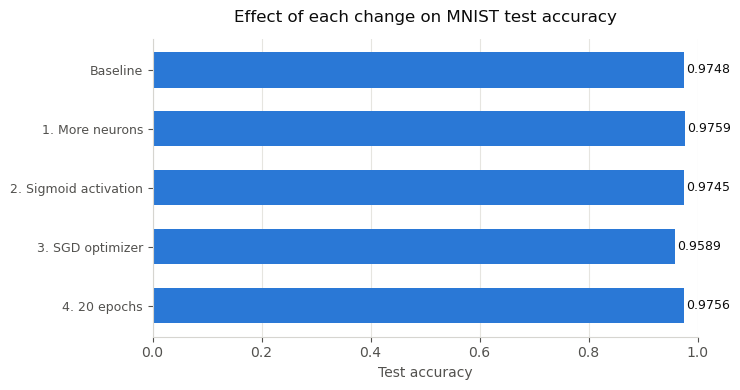

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

SERIES = "#2a78d6"
INK, INK_SOFT = "#0b0b0b", "#52514e"

figure, axes = plt.subplots(figsize=(7.5, 4))

labels = [name.split(" (")[0] for name in results["experiment"]]
positions = np.arange(len(labels))
bars = axes.barh(positions, results["test_accuracy"], height=0.6, color=SERIES)

for bar, value in zip(bars, results["test_accuracy"]):
    axes.text(value + 0.004, bar.get_y() + bar.get_height() / 2, f"{value:.4f}",
              va="center", fontsize=9, color=INK)

axes.set_yticks(positions)
axes.set_yticklabels(labels, fontsize=9)
axes.invert_yaxis()
axes.set_xlim(0, 1.0)
axes.set_xlabel("Test accuracy", color=INK_SOFT)
axes.set_title("Effect of each change on MNIST test accuracy", color=INK, fontsize=12, pad=12)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.xaxis.grid(True, color="#e6e5e0", linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

###What the experiments actually showed

| Experiment | Test accuracy | vs baseline |
|---|---|---|
| Baseline (128-64, relu, adam, 10 epochs) | 0.9748 | — |
| 1. More neurons (256-128) | 0.9759 | +0.0011 |
| 2. Sigmoid activation | 0.9745 | -0.0003 |
| 3. SGD optimizer | 0.9589 | -0.0159 |
| 4. 20 epochs | 0.9756 | +0.0008 |

**More neurons changed almost nothing.** Doubling both hidden layers moved test
accuracy by about a tenth of a percentage point. A fully connected network on
MNIST is already near what this kind of architecture can do, so extra capacity
has nothing left to buy — it only adds parameters to overfit with.

**Sigmoid cost far less than expected — because this network is shallow.** The
theory says sigmoid saturates and gradients vanish, yet the final accuracy is
essentially identical to ReLU. The cost shows up in the *speed*: after one epoch
sigmoid is at 0.8715 training accuracy against ReLU's 0.9236, and it needs most
of the ten epochs to catch up. With only two hidden layers there are too few
layers for the gradient to vanish through. In a deep network the same choice
would be far more damaging.

**SGD is not broken, it is slow.** Its accuracy is the only clearly worse
result, but look at where it ended: training accuracy 0.9624 against the
baseline's 0.9934. It has not overfitted — it has **underfitted**, and its
validation accuracy was still climbing (0.9038 -> 0.9603) when the ten epochs
ran out. Adam reaches in one epoch roughly what SGD reaches in four. Given
enough epochs SGD would close much of the gap; the fixed learning rate simply
makes each step less effective.

**Twice the epochs bought nothing.** Experiment 4 is identical to the baseline
for its first ten epochs (same seed), so the last ten are the interesting part.
Across them training accuracy climbs from 0.9934 to 0.9966 while validation
accuracy stays flat around 0.974, and validation **loss rises** from 0.1083 to
0.1570. The network kept learning the training set and stopped learning the
task. That rising validation loss against a flat validation accuracy is the
clearest overfitting signal in this notebook, and it is the argument for the
early stopping used in the graded tasks.

**The general lesson.** Only one of the four changes made a real difference, and
it made things worse. Hyperparameters are not knobs that reliably improve a
model — most changes do nothing, and the useful information is often in *how*
the training curve moves rather than in the final number.

#End!